In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"zebashine","key":"f63f4f0ef216ffa97fa1e0fa1a96c4b2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tekbahadurkshetri/landslide4sense

Dataset URL: https://www.kaggle.com/datasets/tekbahadurkshetri/landslide4sense
License(s): other
landslide4sense.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip "/content/landslide4sense.zip" -d "/content/drive/MyDrive/data"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3558.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3559.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_356.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3560.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3561.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3562.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3563.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3564.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3565.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3566.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3567.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3568.h5  
  inflating: /content/drive/MyDrive/data/TrainData/img/image_3569.h5  
  inflating: /content/drive

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/data'))
print(os.listdir('/content/drive/MyDrive/data/TrainData'))

['TestData', 'TrainData', 'ValidData']
['img', 'mask']


In [ ]:
import h5py

file = h5py.File('/content/drive/MyDrive/data/TrainData/img/image_1.h5', 'r')
print(list(file.keys()))

['img']


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
import os
import h5py
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", DEVICE)

# ================= DATASET =================
class LandslideDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = os.listdir(img_dir)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]

        img_path = os.path.join(self.img_dir, file_name)

        # IMPORTANT: image → mask
        mask_name = file_name.replace("image", "mask")
        mask_path = os.path.join(self.mask_dir, mask_name)

        img = h5py.File(img_path, 'r')
        mask = h5py.File(mask_path, 'r')

        img_key = list(img.keys())[0]
        mask_key = list(mask.keys())[0]

        image = img[img_key][:]
        mask = mask[mask_key][:]

        if image.shape[-1] == 14:
            image = np.transpose(image, (2, 0, 1))

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

# ================= LOAD DATA =================
train_dataset = LandslideDataset(
    "/content/drive/MyDrive/data/TrainData/img",
    "/content/drive/MyDrive/data/TrainData/mask"
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Total samples:", len(train_dataset))

# ================= MODEL =================
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=14,
    classes=1
).to(DEVICE)

# ================= TRAIN =================
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(imgs)
        loss = loss_fn(outputs, masks.unsqueeze(1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ================= SAVE =================
torch.save(model.state_dict(), "landslide_model.pth")

print("✅ Training Complete!")

Using: cpu
Total samples: 3799
Epoch 1, Loss: 69.6419
Epoch 2, Loss: 41.8222
Epoch 3, Loss: 38.6948
Epoch 4, Loss: 36.6806
Epoch 5, Loss: 36.4178
✅ Training Complete!


In [3]:


# ===============================
# 1. INSTALL (run once)
# ===============================
!pip install segmentation-models-pytorch

# ===============================
# 2. IMPORTS
# ===============================
import os
import h5py
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", DEVICE)

# ===============================
# 3. DATASET CLASS
# ===============================
class LandslideDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))   # ✅ FIX

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]

        # Image path
        img_path = os.path.join(self.img_dir, file_name)

        # Mask path (image → mask)
        mask_name = file_name.replace("image", "mask")
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load files
        img_file = h5py.File(img_path, 'r')
        mask_file = h5py.File(mask_path, 'r')

        img_key = list(img_file.keys())[0]
        mask_key = list(mask_file.keys())[0]

        image = img_file[img_key][:]
        mask = mask_file[mask_key][:]

        # Fix shape (H,W,C → C,H,W)
        if image.shape[-1] == 14:
            image = np.transpose(image, (2, 0, 1))

        # ✅ NORMALIZATION
        image = image / 255.0

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

# ===============================
# 4. LOAD DATA
# ===============================
train_dataset = LandslideDataset(
    "/content/drive/MyDrive/data/TrainData/img",
    "/content/drive/MyDrive/data/TrainData/mask"
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Total samples:", len(train_dataset))

# ===============================
# 5. MODEL (U-NET)
# ===============================
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=14,
    classes=1
).to(DEVICE)

# ===============================
# 6. LOSS + OPTIMIZER
# ===============================
bce = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode='binary')

def loss_fn(outputs, masks):
    return bce(outputs, masks) + dice(outputs, masks)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===============================
# 7. TRAINING LOOP
# ===============================
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(imgs)
        loss = loss_fn(outputs, masks.unsqueeze(1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")

    # 🔥 SAVE AFTER EVERY EPOCH
    torch.save(model.state_dict(), f"/content/drive/MyDrive/landslide_epoch_{epoch+1}.pth")

print("✅ Training complete & model saved in Drive!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00
Using: cuda
Total samples: 3799
Epoch 1/15, Loss: 557.6551
Epoch 2/15, Loss: 477.0008
Epoch 3/15, Loss: 457.0527
Epoch 4/15, Loss: 444.6999
Epoch 5/15, Loss: 431.6780
Epoch 6/15, Loss: 419.6566
Epoch 7/15, Loss: 415.3150
Epoch 8/15, Loss: 415.9124
Epoch 9/15, Loss: 399.6279
Epoch 10/15, Loss: 393.3829
Epoch 11/15, Loss: 397.8088
Epoch 12/15, Loss: 398.3116
Epoch 13/15, Loss: 404.5111
Epoch 14/15, Loss: 389.2924
Epoch 15/15, Loss: 405.3493
✅ Training complete & model saved in Drive!


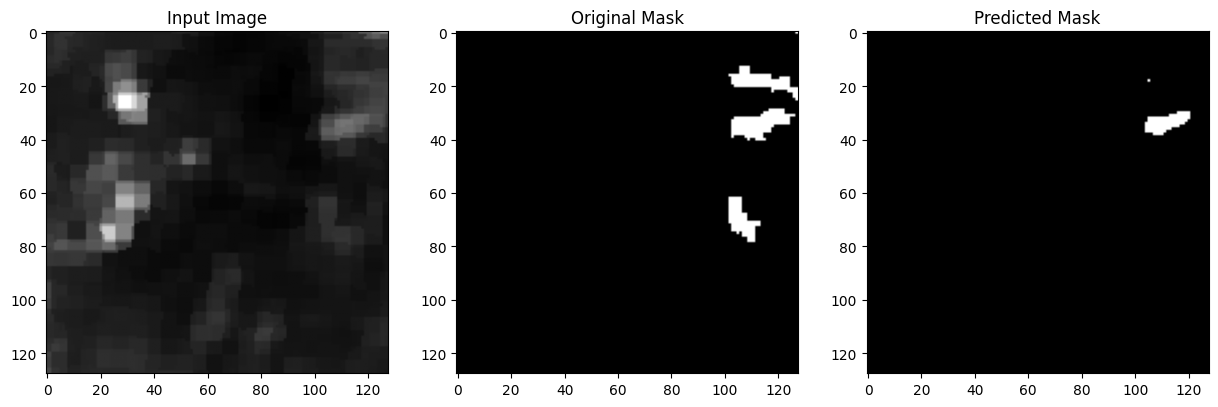

In [4]:
# ===============================
# TEST PREDICTION
# ===============================
import matplotlib.pyplot as plt

model.eval()

# Get one sample
img, mask = train_dataset[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(DEVICE))
    pred = torch.sigmoid(pred)
    pred = pred.squeeze().cpu().numpy()

# Convert prediction to binary
pred = (pred > 0.5).astype(np.uint8)

# Show results
plt.figure(figsize=(15,5))

# Image
plt.subplot(1,3,1)
plt.imshow(img[0], cmap='gray')
plt.title("Input Image")

# Original mask
plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Original Mask")

# Predicted mask
plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray')
plt.title("Predicted Mask")

plt.show()

In [ ]:
# ===============================
# EVALUATION
# ===============================
from sklearn.metrics import accuracy_score

model.eval()

all_acc = []

with torch.no_grad():
    for imgs, masks in train_loader:

        imgs = imgs.to(DEVICE)

        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)

        preds = (outputs > 0.5).float().cpu().numpy()
        masks = masks.numpy()

        acc = accuracy_score(
            masks.flatten(),
            preds.flatten()
        )

        all_acc.append(acc)

print("Accuracy:", np.mean(all_acc))